<a href="https://colab.research.google.com/github/JhonHendricksBautista/CPE313_Bautista-Jhon/blob/main/Assessment_Task_4_1_Supplementary_Activity_on_Transfer_Learning_bautista%2CJhon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assessment Task 4.1 Supplementary Activity on Transfer Learning<br>
This model is for classifying fire on the image

Name: Jhon Hendricks Bautista <br>
Section: CPE32S3 <br>
Date: 02/23/2026 <br>
Instructor: Engr. Neal Barton James Matira

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


I chagne my data transform into 299x299 since this is the input size needed for the inceptionv3 model

In [2]:
from torchvision import transforms, datasets

transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]  # proper normalization
    )
])

dataset = "/content/drive/MyDrive/datasci3/fire_dataset"

full_dataset = datasets.ImageFolder(
    root=dataset,
    transform=transform
)

print("Classes:", full_dataset.classes)


Classes: ['fire_images', 'non_fire_images']


Data Split

In [3]:
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


USING INCEPTION V3

Used the default weights for the model since we are doing transfer learning

In [8]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.inception_v3(
    weights=models.Inception_V3_Weights.DEFAULT,
    aux_logits=True
)
model.fc = nn.Linear(model.fc.in_features, 1)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

model.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [9]:
num_epochs = 10
train_acc_list = []
val_acc_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs, aux_outputs = model(images)

        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)

        loss = loss1 + 0.4 * loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_acc:.4f}")

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    print(f"Validation Loss: {val_loss:.4f} "
          f"Validation Accuracy: {val_acc:.4f}")

    train_acc_list.append(epoch_acc)
    val_acc_list.append(val_acc)

Epoch [1/10] Loss: 0.5924 Accuracy: 0.8755
Validation Loss: 0.2594 Validation Accuracy: 0.8867
Epoch [2/10] Loss: 0.1149 Accuracy: 0.9943
Validation Loss: 0.1488 Validation Accuracy: 0.9400
Epoch [3/10] Loss: 0.0323 Accuracy: 1.0000
Validation Loss: 0.0494 Validation Accuracy: 0.9867
Epoch [4/10] Loss: 0.0147 Accuracy: 1.0000
Validation Loss: 0.0367 Validation Accuracy: 0.9833
Epoch [5/10] Loss: 0.0112 Accuracy: 1.0000
Validation Loss: 0.0382 Validation Accuracy: 0.9833
Epoch [6/10] Loss: 0.0074 Accuracy: 1.0000
Validation Loss: 0.0382 Validation Accuracy: 0.9833
Epoch [7/10] Loss: 0.0102 Accuracy: 1.0000
Validation Loss: 0.0597 Validation Accuracy: 0.9800
Epoch [8/10] Loss: 0.0061 Accuracy: 1.0000
Validation Loss: 0.0626 Validation Accuracy: 0.9800
Epoch [9/10] Loss: 0.0050 Accuracy: 1.0000
Validation Loss: 0.0552 Validation Accuracy: 0.9833
Epoch [10/10] Loss: 0.0046 Accuracy: 1.0000
Validation Loss: 0.0509 Validation Accuracy: 0.9833


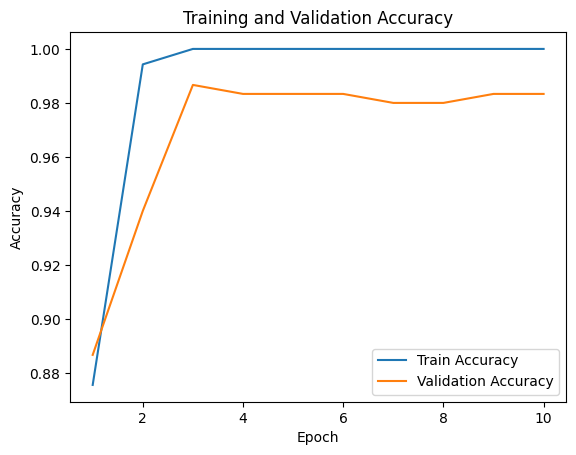

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_list) + 1)

plt.figure()
plt.plot(epochs, train_acc_list, label="Train Accuracy")
plt.plot(epochs, val_acc_list, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

Based on the output of this graph UI can say the model immediately has good performance on this dataset. We can say the model maybe overfitting but the validation is still in good levels since it did not become 100%. I think this is just because the model has good performance.

Testing it into an image

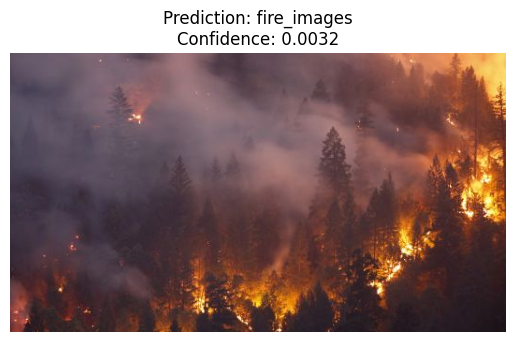

In [25]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

def predict_image(image_path, model, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output)
        pred = (prob > 0.5).float()

    return image, prob.item(), pred.item()

image_path = "/content/drive/MyDrive/datasci3/fire_dataset/fire_images/fire.102.png"

image, probability, prediction = predict_image(image_path, model, device)
class_names = full_dataset.classes
label_name = class_names[int(prediction)]

plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {label_name}\nConfidence: {probability:.4f}")
plt.show()

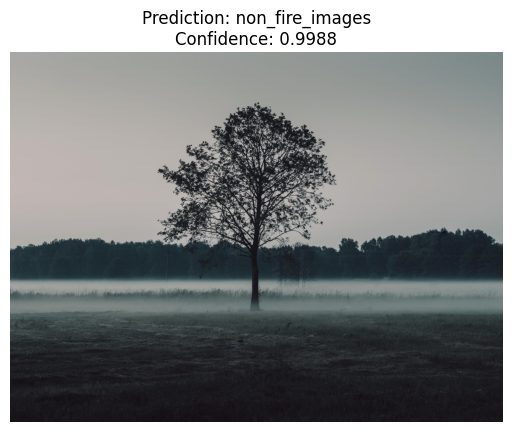

In [24]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

def predict_image(image_path, model, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output)
        pred = (prob > 0.5).float()

    return image, prob.item(), pred.item()

image_path = "/content/drive/MyDrive/datasci3/fire_dataset/non_fire_images/non_fire.10.png"

image, probability, prediction = predict_image(image_path, model, device)
class_names = full_dataset.classes
label_name = class_names[int(prediction)]

plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {label_name}\nConfidence: {probability:.4f}")
plt.show()

# CONCLUSION

After performing this activity I was able to learn about using pre made models and perform transfer learning. I was able to utilize the InceptionV3 model in classifiying fire and non fire presence in images. For this activity I realize that pre trained models makes the work fast not just in building but also in optimization because in this activity I was able to get great performance with minimal tuning. I think based on this activity it is important to tune the inputs and output evaluation for the problem you are solving when using pre trained models this is for you to get the needed results from the transfer learning.